# San Diego Surf Forecast — Exploratory Data Analysis

**Data:** NDBC buoys 46232 & 46254, NWS wind forecasts, NOAA tide gauge, synthetic winter/spring labels

---

## The Story

We're building a classifier that predicts surf quality (POOR / FAIR / GOOD) at three San Diego breaks:
**Blacks Beach**, **La Jolla Shores**, and **PB Point**.

Before any modelling, we need to understand the physical system we're modelling. Good surf is the result of a chain of filters:

> **Deep-ocean swell** → *geographic filter* (does the swell angle match the break?) → *wind filter* (is the surface clean?) → *tide filter* (is the depth right?) → **session rating**

Each notebook section peels back one layer of that chain. By the end we know which features carry real signal, how severe the class imbalance is, and where the model is most likely to struggle.


## Setup

Consolidated imports and constants shared across all sections.

In [1]:
import sys, os, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Rating palette ──────────────────────────────────────────────────────────
RATINGS = ['GOOD', 'FAIR', 'POOR']
COLORS  = {'GOOD': '#2ecc71', 'FAIR': '#f39c12', 'POOR': '#e74c3c'}

# ── Break metadata (from domain.pdf) ────────────────────────────────────────
BREAKS = {
    'blacks':          {'lat': 32.8807, 'lon': -117.2436, 'color': '#e74c3c',
                        'optimal_mwd': 285, 'mwd_range': (270, 300),
                        'offshore_wind': 90,  'tide_range_ft': (0.5, 3.5)},
    'la_jolla_shores': {'lat': 32.8579, 'lon': -117.2575, 'color': '#3498db',
                        'optimal_mwd': 200, 'mwd_range': (180, 220),
                        'offshore_wind': 20,  'tide_range_ft': (2.5, 5.0)},
    'pb_point':        {'lat': 32.7970, 'lon': -117.2550, 'color': '#2ecc71',
                        'optimal_mwd': 290, 'mwd_range': (270, 310),
                        'offshore_wind': 110, 'tide_range_ft': (1.0, 3.5)},
}
BREAK_LABELS = {k: k.replace('_', ' ').title() for k in BREAKS}
BREAK_KEYS   = list(BREAKS.keys())

BUOYS = {
    '46232': {'lat': 32.548, 'lon': -117.424, 'name': 'Point Loma South'},
    '46254': {'lat': 32.748, 'lon': -117.367, 'name': 'Mission Bay West'},
}

FT_PER_M = 3.28084
print('Setup complete.')


Setup complete.


## Data Loading

We pull 30 days of real data from three sources:

- **Buoy** (NDBC) — wave height, dominant period, mean wave direction  
- **Wind** (NWS hourly forecast) — speed and direction at each break  
- **Tide** (NOAA gauge) — water level relative to MLLW


In [2]:
from etl.fetch_buoy import fetch_buoy_swell
from etl.fetch_wind import fetch_wind_all_breaks
from etl.fetch_tide import fetch_tide_heights
from etl.config    import NWS_CACHE_DIR

buoy = fetch_buoy_swell(days=30, use_cache=True)
wind = fetch_wind_all_breaks(cache_dir=NWS_CACHE_DIR)
tide = fetch_tide_heights(days=30)

wind['timestamp_local'] = wind['timestamp_utc'].dt.tz_convert('America/Los_Angeles')
wind['hour_local'] = wind['timestamp_local'].dt.hour

print(f"Buoy: {len(buoy):,} rows  |  stations: {buoy['station'].unique()}")
print(f"Wind: {len(wind):,} rows  |  breaks:   {wind['break_id'].unique()}")
print(f"Tide: {len(tide):,} rows")
buoy.head(3)


Buoy: 2,825 rows  |  stations: ['46232' '46254']
Wind: 468 rows  |  breaks:   ['la_jolla_shores' 'blacks' 'pb_point']
Tide: 723 rows


,timestamp_utc,station,WVHT,DPD,MWD,APD
0,2026-05-27 00:56:00+00:00,46232,1.3,15,197,6.6
1,2026-05-27 00:26:00+00:00,46232,1.4,14,206,6.4
2,2026-05-26 23:56:00+00:00,46232,1.4,14,195,6.9


---

## 1 — The Ocean Engine: Raw Swell Characteristics

*Where does the wave energy come from, and is it organized?*

Before a wave reaches a beach it has to cross the Pacific as a swell. The two numbers that matter most are:

- **WVHT (significant wave height)** — how tall the waves are at the buoy. Necessary but not sufficient for good surf.
- **DPD (dominant period)** — seconds between wave crests. This is the single most important quality indicator. A long period (≥ 12 s) means the swell traveled from a distant storm and each wave is fully organized and powerful. A short period (< 8 s) is local wind chop — messy and weak.

We also engineer two features here:
- **Swell energy proxy** = WVHT² × DPD — captures both size and organisation in one number.
- **Period gap** (DPD − APD) — a large gap means a clean swell is cutting above the background ocean noise.


In [3]:
# ── Feature engineering ─────────────────────────────────────────────────────
buoy['swell_energy'] = (buoy['WVHT'] ** 2) * buoy['DPD']
buoy['period_gap']   = buoy['DPD'] - buoy['APD']

dpd_conditions = [
    (buoy['DPD'] <= 7),
    (buoy['DPD'] > 7)  & (buoy['DPD'] <= 11),
    (buoy['DPD'] > 11) & (buoy['DPD'] <= 14),
    (buoy['DPD'] > 14),
]
dpd_choices = ['Weak (<7s)', 'Moderate (7–11s)', 'Good (11–14s)', 'Excellent (>14s)']
buoy['dpd_category'] = np.select(dpd_conditions, dpd_choices, default='Unknown')

# ── Wave quality scatter: DPD vs WVHT ───────────────────────────────────────
fig = px.scatter(
    buoy, x='DPD', y='WVHT', color='dpd_category',
    title='Wave Quality: Period vs Height<br><sup>Good surf lives in the top-right — tall waves AND long period</sup>',
    labels={'DPD': 'Dominant Period (s)', 'WVHT': 'Wave Height (m)', 'dpd_category': 'Period class'},
    category_orders={'dpd_category': dpd_choices},
)
fig.show()

# ── Period gap distribution ──────────────────────────────────────────────────
fig_gap = px.histogram(
    buoy, x='period_gap', color='dpd_category',
    title='Swell Cleanliness: DPD − APD Gap<br><sup>Larger gap = dominant swell cuts above background noise</sup>',
    labels={'period_gap': 'DPD − APD (s)', 'dpd_category': 'Period class'},
    category_orders={'dpd_category': dpd_choices},
)
fig_gap.show()

# ── Time series of wave height ───────────────────────────────────────────────
fig_ts = px.line(
    buoy, x='timestamp_utc', y='WVHT', color='station',
    title='Wave Height Over Time — 30-day buoy record',
    labels={'timestamp_utc': 'Date (UTC)', 'WVHT': 'Wave Height (m)'},
)
fig_ts.show()


---

## 2 — The Geographic Filter: Swell Direction & Break Alignment

*Raw swell energy is useless if it arrives from the wrong angle.*

Every surf break has an optimal swell direction determined by how the coastline and seafloor are oriented. The three SD breaks we're modelling face very different directions:

| Break | Optimal swell window | Why |
|-------|---------------------|-----|
| Blacks Beach | 270–300° (West/NW) | Underwater canyon focuses NW groundswell |
| La Jolla Shores | 180–220° (South/SW) | Sandy beach opens to southern hemisphere swells |
| PB Point | 270–310° (West/NW) | Mixed reef benefits from similar NW angle to Blacks |

This section validates that the buoy data reflects these differences. The key test: when the swell is from the west, Blacks and PB Point should score high while La Jolla scores low — and vice versa for south swells.


### 2.1 — Break & Buoy Map

Orientation: where are the breaks relative to the buoys?

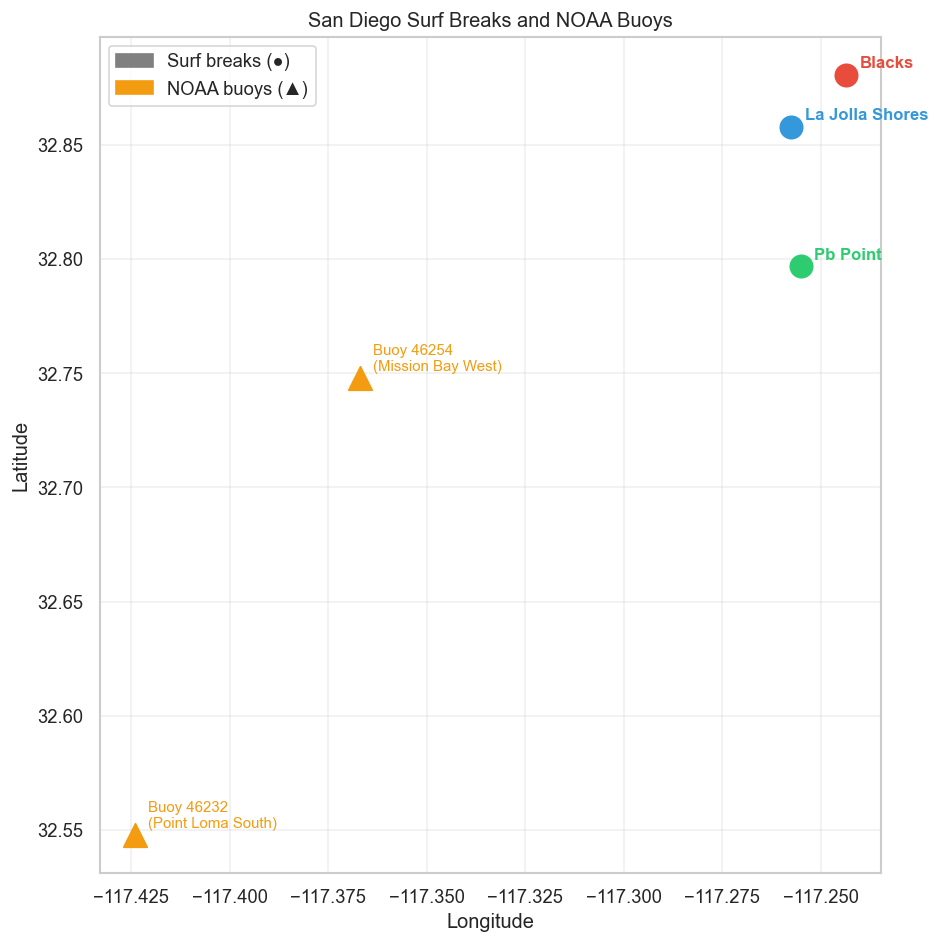

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

for name, b in BREAKS.items():
    ax.scatter(b['lon'], b['lat'], s=180, color=b['color'], zorder=5)
    ax.annotate(BREAK_LABELS[name], (b['lon'], b['lat']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=10, color=b['color'], fontweight='bold')

for sid, b in BUOYS.items():
    ax.scatter(b['lon'], b['lat'], s=200, color='#f39c12', zorder=5, marker='^')
    ax.annotate(f"Buoy {sid}\n({b['name']})", (b['lon'], b['lat']),
                textcoords='offset points', xytext=(8, 4), fontsize=9, color='#f39c12')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('San Diego Surf Breaks and NOAA Buoys')
ax.grid(True, alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color='gray',    label='Surf breaks (●)'),
    mpatches.Patch(color='#f39c12', label='NOAA buoys (▲)'),
])
plt.tight_layout()
plt.show()


### 2.2 — Swell Direction Rose

Which directions does SD swell most commonly arrive from? Each break's optimal window is overlaid as a shaded arc.

We expect most energy to come from the NW quadrant (270–320°) because Pacific storm tracks run from NW to SE during winter. South swells from southern hemisphere storms are less frequent but produce the best La Jolla Shores days.


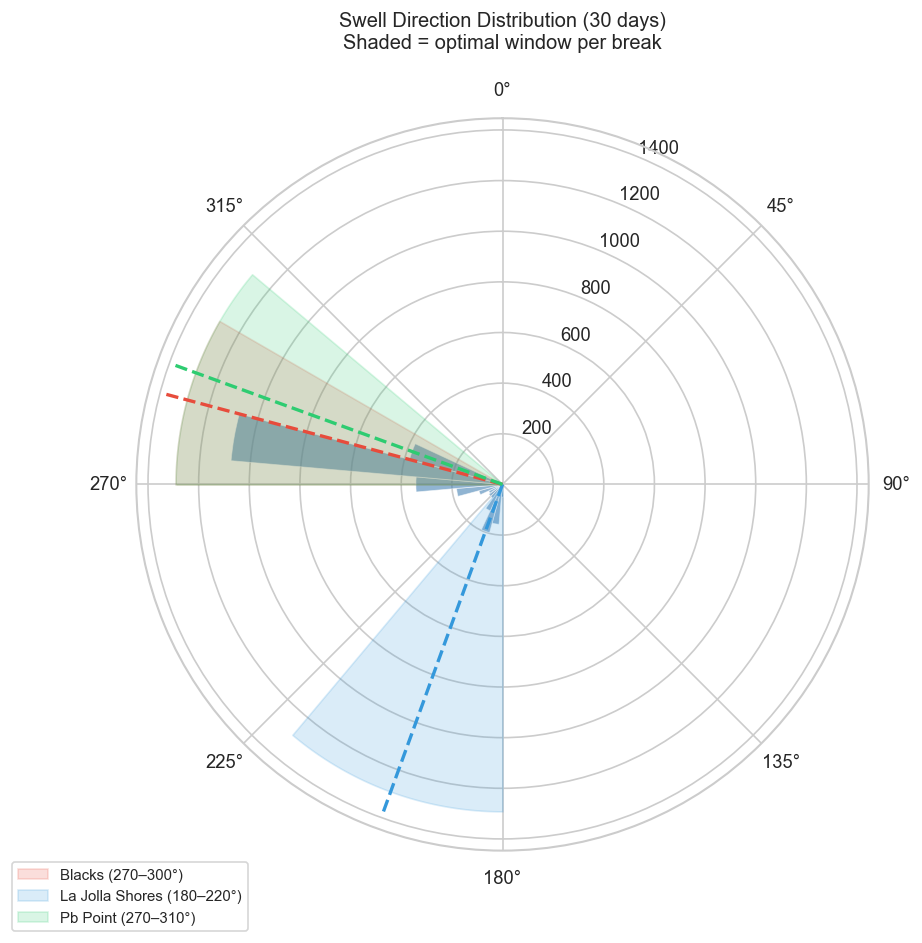

MWD summary (degrees):
count    2825.0
mean      263.8
std        33.7
min       145.0
25%       247.0
50%       280.0
75%       288.0
max       309.0
Name: MWD, dtype: float64


In [5]:
mwd = buoy['MWD'].dropna()

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

n_bins = 36
bin_edges = np.linspace(0, 360, n_bins + 1)
counts, _ = np.histogram(mwd, bins=bin_edges)
theta = np.deg2rad(bin_edges[:-1])
width = np.deg2rad(360 / n_bins)

ax.bar(theta, counts, width=width, bottom=0, alpha=0.6,
       color='steelblue', edgecolor='white', linewidth=0.5)

for name, b in BREAKS.items():
    lo, hi = b['mwd_range']
    span = np.linspace(np.deg2rad(lo), np.deg2rad(hi), 50)
    ax.fill_between(span, 0, counts.max() * 1.2, alpha=0.18,
                    color=b['color'],
                    label=f"{BREAK_LABELS[name]} ({lo}–{hi}°)")
    ax.plot([np.deg2rad(b['optimal_mwd'])] * 2, [0, counts.max() * 1.28],
            color=b['color'], linewidth=2, linestyle='--')

ax.set_title('Swell Direction Distribution (30 days)\nShaded = optimal window per break', pad=20)
ax.legend(loc='lower left', bbox_to_anchor=(-0.18, -0.12), fontsize=9)
plt.tight_layout()
plt.show()

print("MWD summary (degrees):")
print(mwd.describe().round(1))


### 2.3 — Direction Score Per Break

For every buoy observation we score how well the incoming swell direction aligns with each break's optimal angle:

```
score = 1 − angular_distance(MWD, optimal) / 180
```

A score of 1.0 means perfect alignment; 0.0 means the worst possible direction. This becomes a continuous feature for the model and is more expressive than a binary "in window / out of window" flag.


In [6]:
def angular_distance(a, b):
    diff = np.abs(a - b) % 360
    return np.where(diff > 180, 360 - diff, diff)

def swell_dir_score(mwd_series, optimal_deg):
    return 1 - angular_distance(mwd_series, optimal_deg) / 180

df_buoy = buoy[['timestamp_utc', 'station', 'MWD', 'WVHT', 'DPD', 'APD']].dropna(subset=['MWD']).copy()

for name, b in BREAKS.items():
    df_buoy[f'dir_score_{name}'] = swell_dir_score(df_buoy['MWD'], b['optimal_mwd'])

score_cols = [f'dir_score_{n}' for n in BREAK_KEYS]
print("Mean direction score per break (30 days):")
print(df_buoy[score_cols].mean().round(3).rename(lambda c: c.replace('dir_score_', '')))


Mean direction score per break (30 days):
blacks             0.862
la_jolla_shores    0.639
pb_point           0.848
dtype: float64


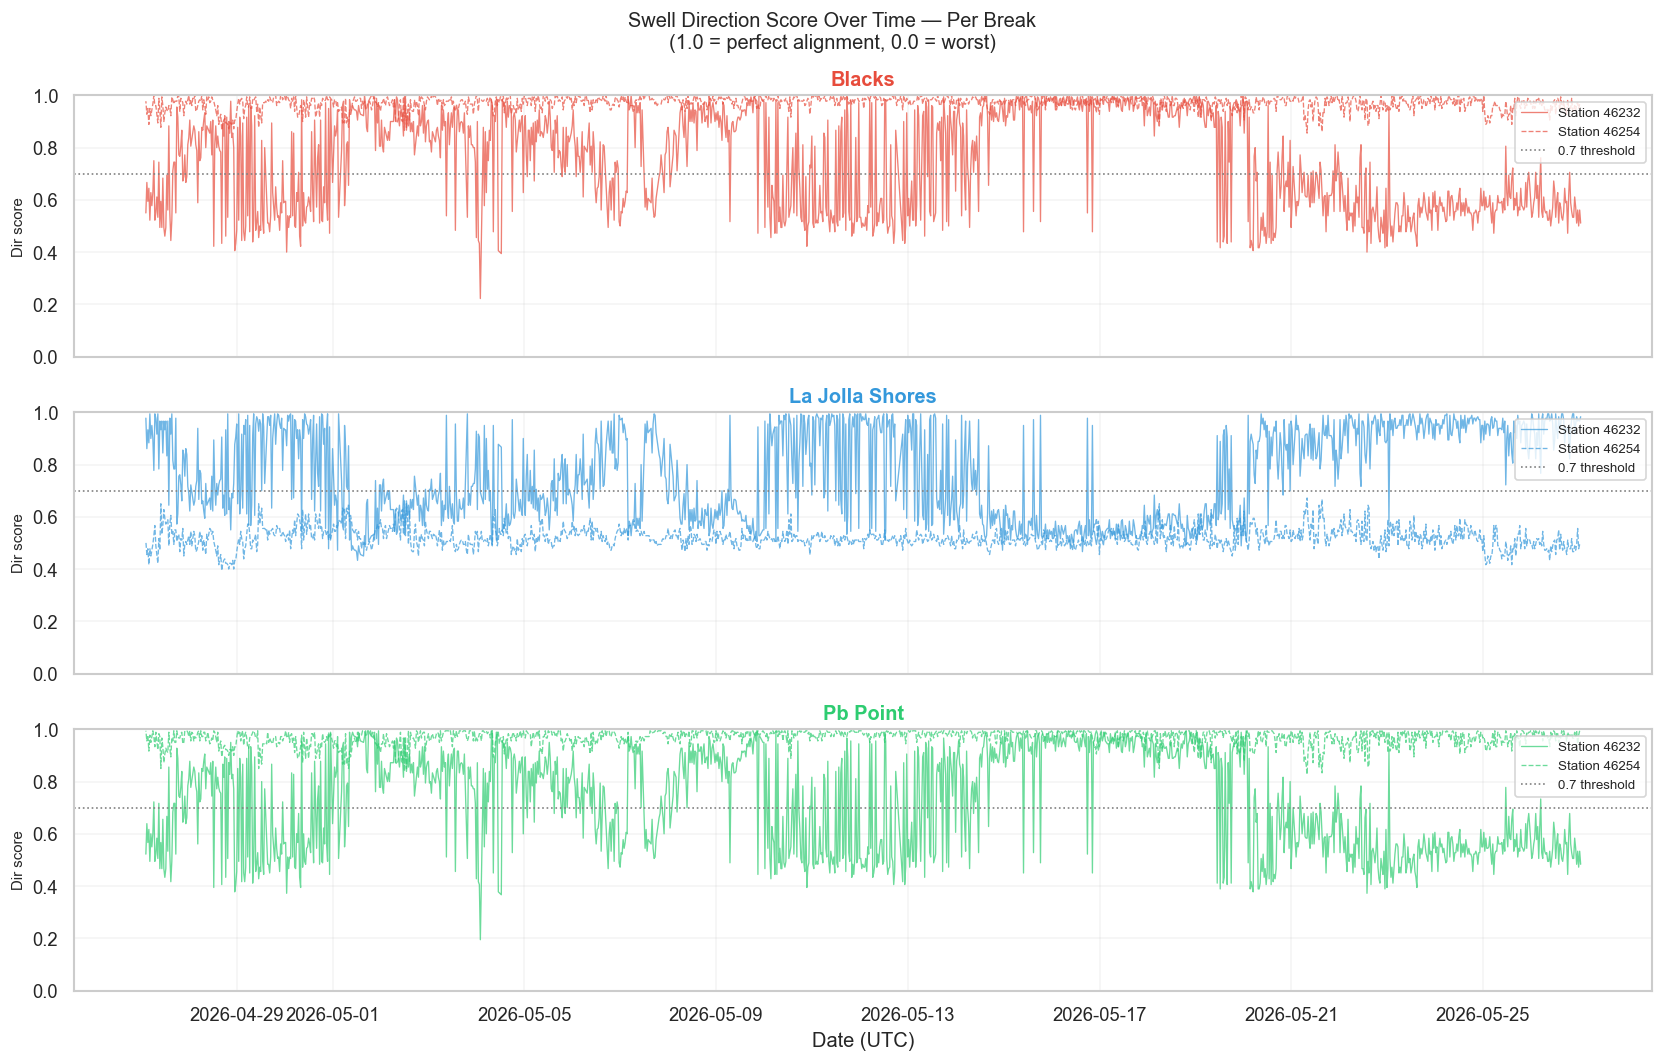

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, name in zip(axes, BREAK_KEYS):
    col   = f'dir_score_{name}'
    color = BREAKS[name]['color']
    for station, grp in df_buoy.groupby('station'):
        ax.plot(grp['timestamp_utc'], grp[col], alpha=0.7, linewidth=0.8, color=color,
                linestyle='-' if station == '46232' else '--', label=f'Station {station}')
    ax.axhline(0.7, color='gray', linestyle=':', linewidth=1, label='0.7 threshold')
    ax.set_ylabel('Dir score', fontsize=9)
    ax.set_title(BREAK_LABELS[name], color=color, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Date (UTC)')
fig.suptitle('Swell Direction Score Over Time — Per Break\n(1.0 = perfect alignment, 0.0 = worst)', fontsize=12)
plt.tight_layout()
plt.show()


### 2.4 — The Key Validation: West Swell vs South Swell

If domain knowledge is correct, the two swell windows should produce opposite rankings across breaks:

- **West swell (270–300°):** Blacks ✓, PB Point ✓, La Jolla ✗  
- **South swell (180–220°):** La Jolla ✓, Blacks ✗, PB Point ✗  

This is the most important chart in the geographical EDA. If the scores don't diverge cleanly, our break-specific direction features won't add much to the model.


West swell hours  (270–300°): 1798
South swell hours (180–220°): 520


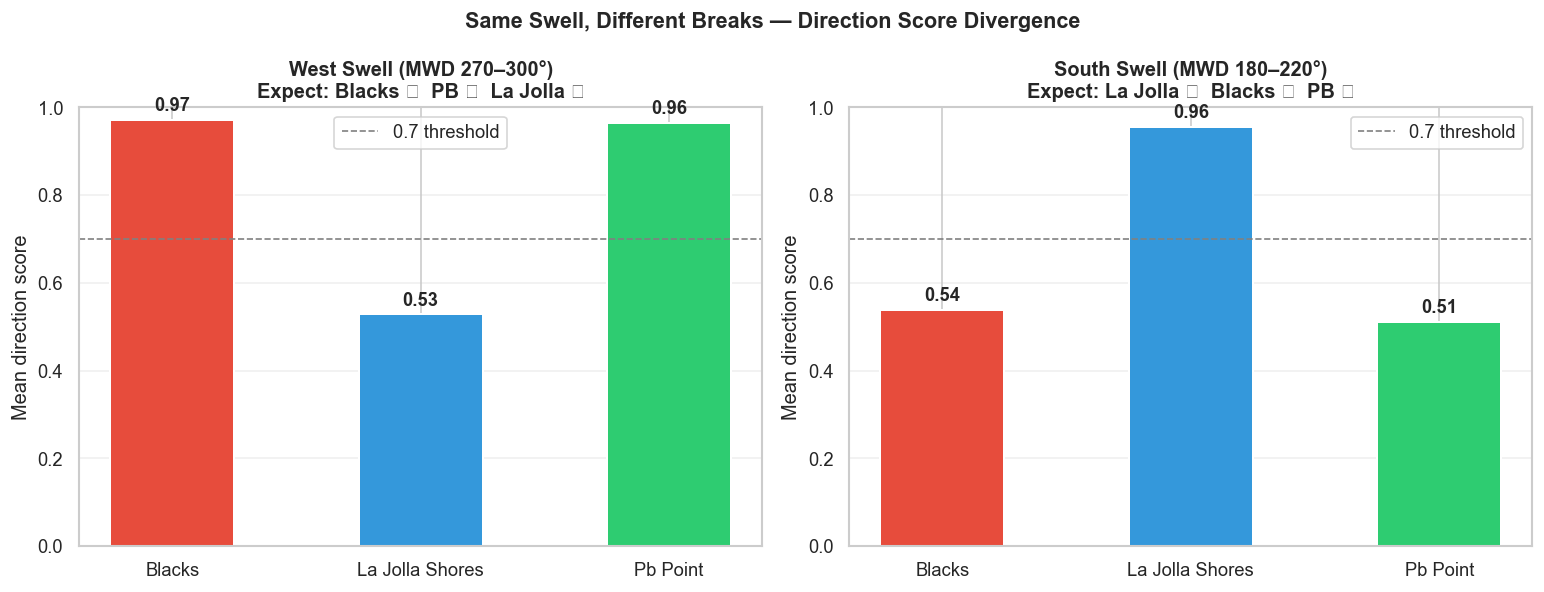

In [8]:
west_swell  = df_buoy[(df_buoy['MWD'] >= 270) & (df_buoy['MWD'] <= 300)]
south_swell = df_buoy[(df_buoy['MWD'] >= 180) & (df_buoy['MWD'] <= 220)]

print(f"West swell hours  (270–300°): {len(west_swell)}")
print(f"South swell hours (180–220°): {len(south_swell)}")

x            = np.arange(len(BREAK_KEYS))
colors_list  = [BREAKS[k]['color'] for k in BREAK_KEYS]
break_labels = [BREAK_LABELS[k] for k in BREAK_KEYS]

west_means  = [west_swell[f'dir_score_{k}'].mean()  for k in BREAK_KEYS]
south_means = [south_swell[f'dir_score_{k}'].mean() for k in BREAK_KEYS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, means, title in zip(
    axes,
    [west_means, south_means],
    ['West Swell (MWD 270–300°)\nExpect: Blacks ✓  PB ✓  La Jolla ✗',
     'South Swell (MWD 180–220°)\nExpect: La Jolla ✓  Blacks ✗  PB ✗']
):
    bars = ax.bar(x, means, width=0.5, color=colors_list, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(break_labels)
    ax.set_ylabel('Mean direction score'); ax.set_ylim(0, 1)
    ax.axhline(0.7, color='gray', linestyle='--', linewidth=1, label='0.7 threshold')
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
                ha='center', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)

fig.suptitle('Same Swell, Different Breaks — Direction Score Divergence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.5 — Which Break Has the Best Alignment Each Hour?

For every buoy observation, which break has the highest direction score? This shows how much of the 30-day window each break is "in season."

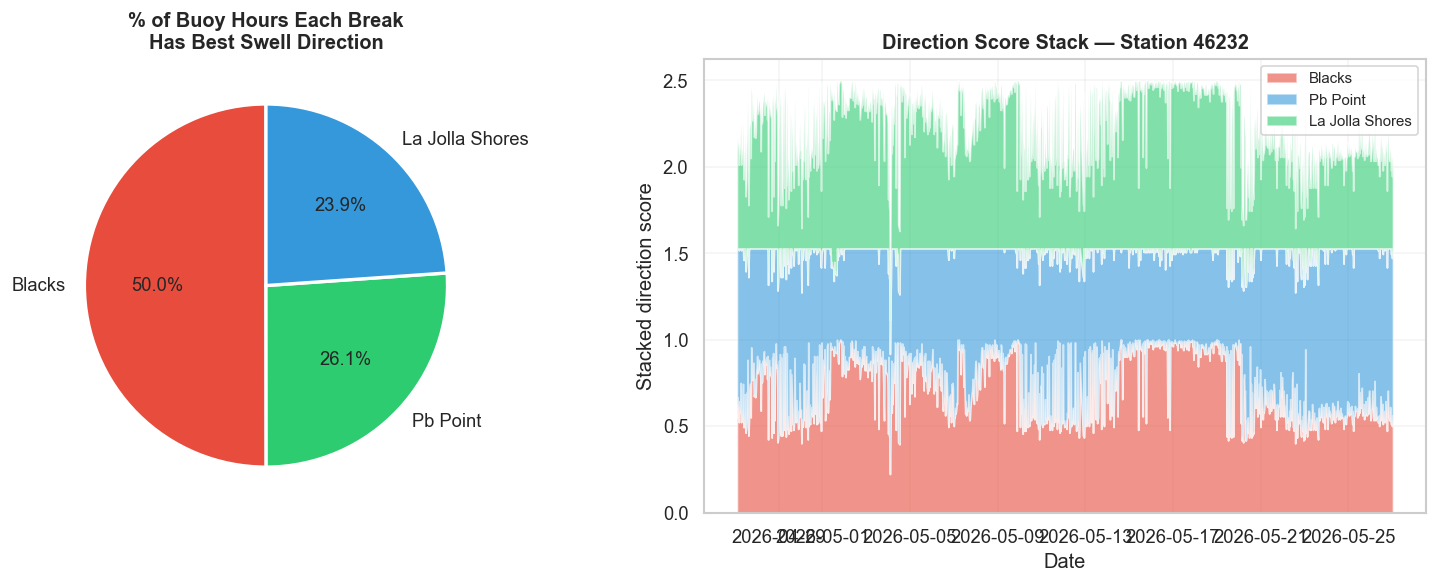

Hours each break is the best-aligned:
best_break
Blacks             1413
Pb Point            737
La Jolla Shores     675
Name: count, dtype: int64


In [9]:
df_buoy['best_break'] = (
    df_buoy[score_cols].idxmax(axis=1).str.replace('dir_score_', '')
)
counts_bb   = df_buoy['best_break'].value_counts()
pie_colors  = [BREAKS[k]['color'] for k in counts_bb.index]
pie_labels  = [BREAK_LABELS[k] for k in counts_bb.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(counts_bb.values, labels=pie_labels, colors=pie_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('% of Buoy Hours Each Break\nHas Best Swell Direction', fontweight='bold')

df_one = df_buoy[df_buoy['station'] == '46232'].sort_values('timestamp_utc')
axes[1].stackplot(df_one['timestamp_utc'],
                  [df_one[f'dir_score_{k}'] for k in BREAK_KEYS],
                  labels=pie_labels, colors=[BREAKS[k]['color'] for k in BREAK_KEYS], alpha=0.6)
axes[1].set_title('Direction Score Stack — Station 46232', fontweight='bold')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Stacked direction score')
axes[1].legend(loc='upper right', fontsize=9); axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Hours each break is the best-aligned:")
print(counts_bb.rename(index=BREAK_LABELS))


### 2.6 — Categorised Swell Alignment by Break

Combining direction, height, and period into a single "optimal for this break" flag gives a clean visual summary of which observations the model should find easiest to label correctly.


In [10]:
conditions = [
    (buoy['MWD'].between(270, 300)) & (buoy['WVHT'] >= 1.5) & (buoy['DPD'] >= 12),
    (buoy['MWD'].between(300, 310)) & (buoy['WVHT'] >= 1.5) & (buoy['DPD'] >= 12),
    (buoy['MWD'].between(180, 220)) & (buoy['WVHT'] >= 1.5) & (buoy['DPD'] >= 12),
]
choices = ['Blacks & PB Point', 'PB Point Only', 'La Jolla Shores']
buoy['optimal_break'] = np.select(conditions, choices, default='Sub-optimal / Other')

fig = px.scatter_polar(
    buoy, r='WVHT', theta='MWD', color='optimal_break', size='DPD',
    title='Swell Alignment by Break<br><sup>Optimal = meets direction, WVHT ≥ 1.5m, DPD ≥ 12s; dot size = period</sup>',
    color_discrete_map={
        'Blacks & PB Point': '#EF553B',
        'PB Point Only':     '#FFA15A',
        'La Jolla Shores':   '#00CC96',
        'Sub-optimal / Other': '#E5ECF6',
    }
)
fig.update_layout(polar=dict(radialaxis=dict(rangemode='tozero')))
fig.show()


---

## 3 — The Wind Destroyer: San Diego's Diurnal Wind Cycle

*Even perfect swell gets ruined if the wind is wrong.*

Wind chops up the wave face, collapsing waves before they properly form. San Diego has one of the most predictable daily wind patterns in the world:

- **Dawn (5–10 am):** Air is still. Wind is light and sometimes briefly offshore (easterly). Best window for clean surf.
- **Late morning:** The land heats up and pulls cool ocean air inshore — the **sea breeze** switches on.
- **Afternoon (12–6 pm):** Onshore westerly wind builds to 10–15 mph, systematically degrading wave quality.

This makes **hour of day one of the strongest predictive features we can give the model** — a session at 7 am and one at 2 pm can have identical swell and tide readings but completely different ratings.


### 3.1 — Average Wind Speed by Hour of Day

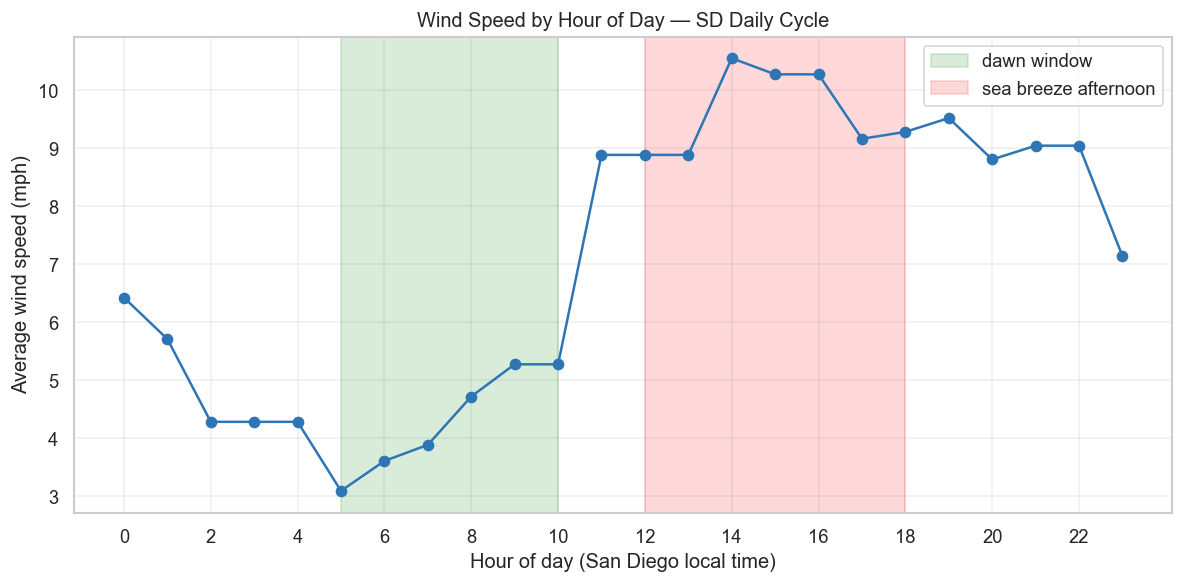

Dawn average (5–10am): 4.3 mph
Peak: 10.6 mph at 14:00


In [11]:
hourly_wind = wind.groupby('hour_local')['wind_speed_mph'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_wind.index, hourly_wind.values, marker='o', color='#2E75B6')
plt.axvspan(5, 10, alpha=0.15, color='green', label='dawn window')
plt.axvspan(12, 18, alpha=0.15, color='red',   label='sea breeze afternoon')
plt.xlabel('Hour of day (San Diego local time)')
plt.ylabel('Average wind speed (mph)')
plt.title('Wind Speed by Hour of Day — SD Daily Cycle')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

peak_mph  = hourly_wind.max()
peak_hour = hourly_wind.idxmax()
dawn_mph  = hourly_wind[5:11].mean()
print(f"Dawn average (5–10am): {dawn_mph:.1f} mph")
print(f"Peak: {peak_mph:.1f} mph at {peak_hour:02d}:00")


Wind averages ~5 mph at dawn and nearly doubles to ~11–12 mph by mid-afternoon, with the sharpest single-hour jump around 10–11 am when the sea breeze switches on. **Hour of day alone captures most of the wind variance in this dataset.**


### 3.2 — Wind Direction by Hour and Break

All three breaks sit in the 260–300° range (westerly, onshore) through most of the day. Blacks briefly shifts toward SSW (~198°) around 6–7 am — a possible offshore-adjacent window that the other breaks don't share.

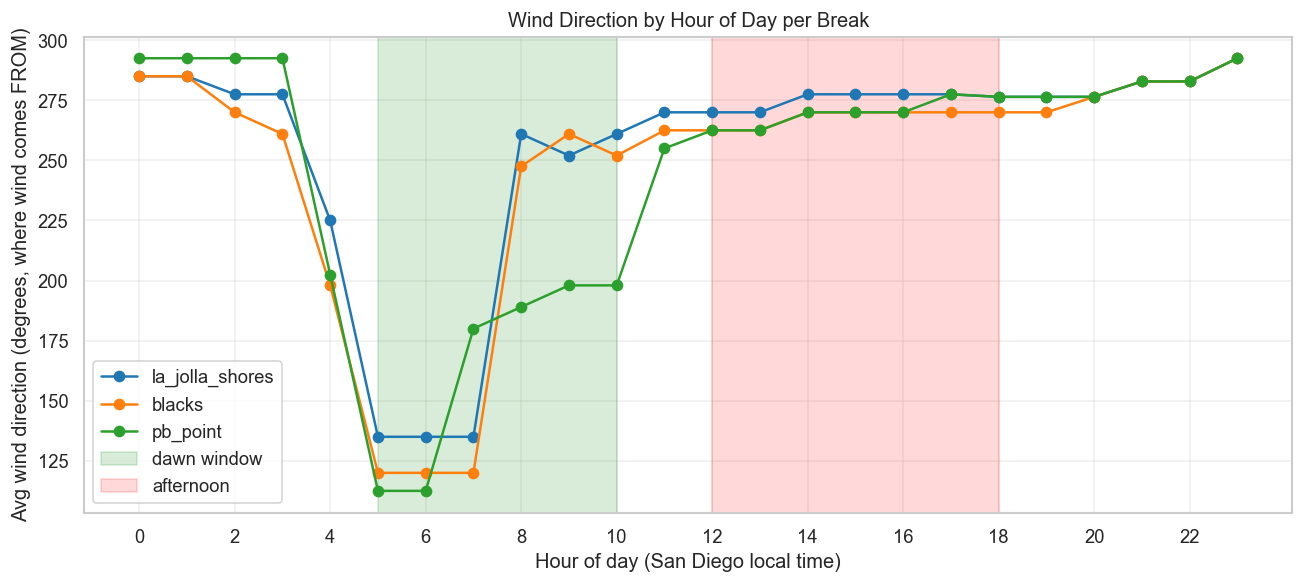

In [12]:
plt.figure(figsize=(11, 5))
for break_id in wind['break_id'].unique():
    subset     = wind[wind['break_id'] == break_id]
    hourly_dir = subset.groupby('hour_local')['wind_direction_degrees'].mean()
    plt.plot(hourly_dir.index, hourly_dir.values, marker='o', label=break_id)

plt.axvspan(5, 10, alpha=0.15, color='green', label='dawn window')
plt.axvspan(12, 18, alpha=0.15, color='red',  label='afternoon')
plt.xlabel('Hour of day (San Diego local time)')
plt.ylabel('Avg wind direction (degrees, where wind comes FROM)')
plt.title('Wind Direction by Hour of Day per Break')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 3.3 — Morning vs Midday: Wind Speed Doubles at Every Break

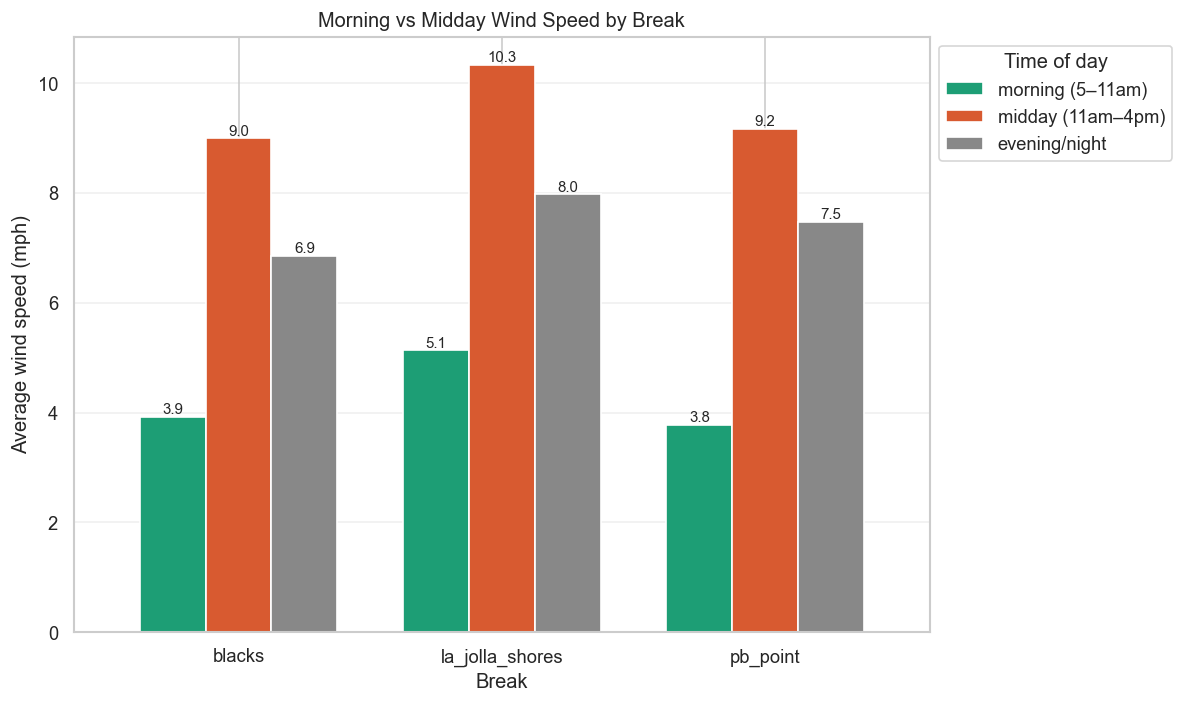

In [13]:
def classify_time(h):
    if 5 <= h < 11:    return 'morning (5–11am)'
    elif 11 <= h < 16: return 'midday (11am–4pm)'
    else:              return 'evening/night'

wind['time_block'] = wind['hour_local'].map(classify_time)

pivot = (
    wind.groupby(['break_id', 'time_block'])['wind_speed_mph']
    .mean().unstack()
    [['morning (5–11am)', 'midday (11am–4pm)', 'evening/night']]
)

ax = pivot.plot(kind='bar', figsize=(10, 6),
                color=['#1D9E75', '#D85A30', '#888888'], width=0.75)
ax.set_xlabel('Break'); ax.set_ylabel('Average wind speed (mph)')
ax.set_title('Morning vs Midday Wind Speed by Break')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Time of day', loc='upper left', bbox_to_anchor=(1.0, 1.0))
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)
plt.tight_layout()
plt.show()


### 3.4 — Wind Offshore Score Per Break

How offshore is the wind at each break? An offshore score of 1.0 means the wind is blowing perfectly away from the beach (grooming the wave face); 0.0 means perfectly onshore (destroying it).

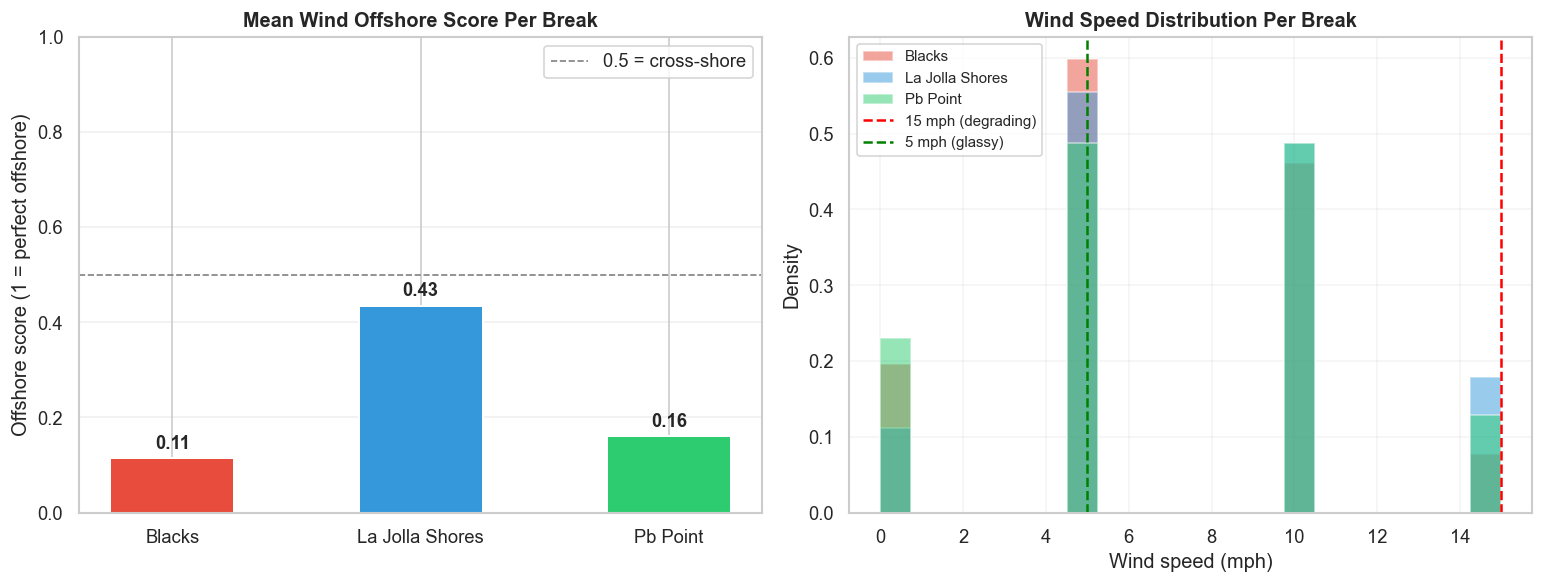

In [14]:
def offshore_score(wind_dir_series, offshore_deg):
    dist = angular_distance(wind_dir_series, offshore_deg)
    return 1 - dist / 180

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mean_offshore = {}
for name, b in BREAKS.items():
    grp = wind[wind['break_id'] == name].copy()
    if grp.empty:
        mean_offshore[name] = np.nan
        continue
    grp['offshore_score'] = offshore_score(grp['wind_direction_degrees'], b['offshore_wind'])
    mean_offshore[name]   = grp['offshore_score'].mean()

bar_colors = [BREAKS[k]['color'] for k in BREAKS]
bar_labels = [BREAK_LABELS[k] for k in BREAKS]

bars = axes[0].bar(bar_labels, mean_offshore.values(), color=bar_colors,
                   edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_title('Mean Wind Offshore Score Per Break', fontweight='bold')
axes[0].set_ylabel('Offshore score (1 = perfect offshore)')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='0.5 = cross-shore')
for bar, val in zip(bars, mean_offshore.values()):
    if not np.isnan(val):
        axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                     f'{val:.2f}', ha='center', fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

for name, b in BREAKS.items():
    grp = wind[wind['break_id'] == name]
    if not grp.empty:
        axes[1].hist(grp['wind_speed_mph'], bins=20, alpha=0.5,
                     color=b['color'], label=BREAK_LABELS[name], density=True)
axes[1].axvline(15, color='red',   linestyle='--', linewidth=1.5, label='15 mph (degrading)')
axes[1].axvline(5,  color='green', linestyle='--', linewidth=1.5, label='5 mph (glassy)')
axes[1].set_title('Wind Speed Distribution Per Break', fontweight='bold')
axes[1].set_xlabel('Wind speed (mph)'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


---

## 4 — The Tide Constraint: Preferred Water Level Per Break

*Waves break when they hit the right depth. Too much or too little water and the break doesn't work.*

Each break has a preferred tide window determined by its underwater shape:

| Break | Preferred window | Why |
|-------|-----------------|-----|
| Blacks Beach | 0.5–3.5 ft | Submarine canyon focuses swell better at lower water |
| La Jolla Shores | 2.5–5.0 ft | Sandy beach needs enough depth to prevent closeouts |
| PB Point | 1.0–3.5 ft | Mixed sand and reef, works at moderate depth |

A window hit means the tide is within 0.5 ft of the break's preferred range. Anything outside is a POOR tide — the break just doesn't work regardless of swell quality.


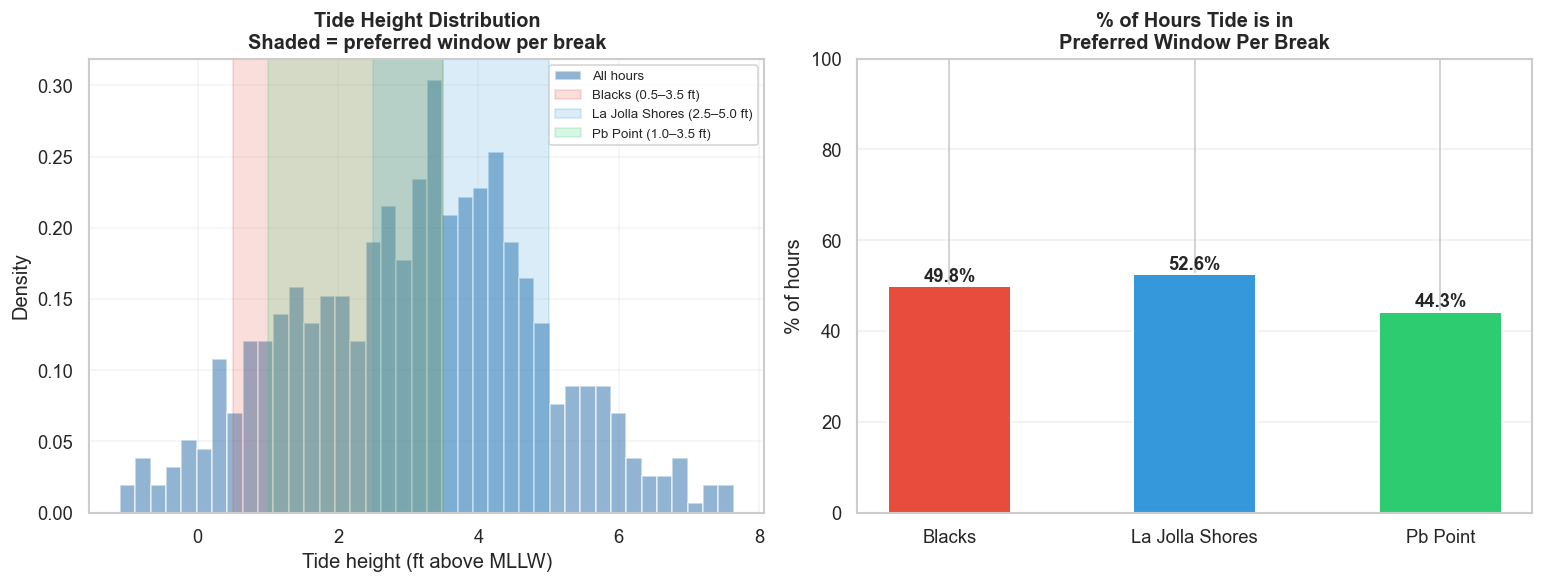


Tide summary (feet above MLLW):
count    723.00
mean       3.13
std        1.72
min       -1.11
25%        1.86
50%        3.27
75%        4.31
max        7.64
Name: tide_height_ft, dtype: float64


In [15]:
tide_ft = tide.copy()
tide_ft['tide_height_ft'] = tide_ft['tide_height_m'] * FT_PER_M

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(tide_ft['tide_height_ft'], bins=40, color='steelblue',
             alpha=0.6, edgecolor='white', density=True, label='All hours')
for name, b in BREAKS.items():
    lo, hi = b['tide_range_ft']
    axes[0].axvspan(lo, hi, alpha=0.18, color=b['color'],
                    label=f"{BREAK_LABELS[name]} ({lo}–{hi} ft)")
axes[0].set_xlabel('Tide height (ft above MLLW)')
axes[0].set_ylabel('Density')
axes[0].set_title('Tide Height Distribution\nShaded = preferred window per break', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.2)

pct_in_window = {}
for name, b in BREAKS.items():
    lo, hi = b['tide_range_ft']
    pct_in_window[name] = ((tide_ft['tide_height_ft'] >= lo) &
                           (tide_ft['tide_height_ft'] <= hi)).mean() * 100

bars = axes[1].bar(bar_labels, pct_in_window.values(), color=bar_colors,
                   edgecolor='white', linewidth=1.2, width=0.5)
axes[1].set_title('% of Hours Tide is in\nPreferred Window Per Break', fontweight='bold')
axes[1].set_ylabel('% of hours'); axes[1].set_ylim(0, 100)
for bar, val in zip(bars, pct_in_window.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTide summary (feet above MLLW):")
print(tide_ft['tide_height_ft'].describe().round(2))


---

## 5 — The Target Variable: Label Distribution & Class Imbalance

*Now that we understand the physical system, what does it actually produce?*

We derive session ratings by applying per-feature labelers to 180 days of synthetic winter/spring data (Oct 2025 – Mar 2026). The synthetic data is parameterised from SD surf statistics:

- Wave height: log-normal, skewed larger in winter when NW groundswell is most active
- Period: bimodal — 30% groundswell (12–22 s), 70% short-period wind swell (4–12 s)  
- Wind: SD's diurnal cycle — calm easterly at dawn, westerly sea breeze by mid-afternoon
- Tide: semi-diurnal pattern (~two highs and two lows per 12.4 hours)

Each feature is labelled independently on its own POOR / FAIR / GOOD scale and votes for the overall session rating. The **model** learns how those votes interact — we don't hard-code the combinations.

> **Swap point:** replace the synthetic `df` with real Surfline labels when `fetch_labels.py` is ready. Every section below runs unchanged.


### 5.1 — Feature Labeler Definitions

One function per feature. Each looks only at its own metric and knows nothing about the others — a poor tide has no effect on the wave height label.

In [17]:
# ── Feature labelers ─────────────────────────────────────────────────────────

def label_wvht(m):
    """Wave height (meters). GOOD: 1.0–2.5m (head high to overhead). POOR: flat or dangerously large."""    
    ft = m * 3.281
    if ft < 1.6 or ft > 9.8: return 'POOR'
    if ft < 3.3 or ft > 8.2: return 'FAIR'
    return 'GOOD'

def label_dpd(s):
    """Dominant period (seconds). GOOD: ≥12s (organised groundswell). POOR: <8s (wind chop)."""    
    if s < 8:  return 'POOR'
    if s < 12: return 'FAIR'
    return 'GOOD'

def label_wind_speed(mph, dpd):
    """Wind speed (mph). Exception: >18s swell gets a 3 mph buffer (strong swell holds shape)."""    
    limit = 18 if dpd > 18 else 15
    if mph > limit: return 'POOR'
    if mph > 10:    return 'FAIR'
    return 'GOOD'

def label_wind_dir(degrees):
    """Wind direction. GOOD: within 45° of east (offshore). POOR: >90° from east (onshore)."""    
    delta = abs((degrees - 90 + 180) % 360 - 180)
    if delta <= 45: return 'GOOD'
    if delta <= 90: return 'FAIR'
    return 'POOR'

TIDE_WIN = {
    'blacks':          (0.5, 3.5),
    'la_jolla_shores': (2.5, 5.0),
    'pb_point':        (1.0, 3.5),
}

def label_tide(ft, brk):
    """Tide height vs break-specific preferred window. FAIR if within 0.5 ft of edge."""    
    lo, hi = TIDE_WIN[brk]
    if lo <= ft <= hi:              return 'GOOD'
    if lo - 0.5 <= ft <= hi + 0.5: return 'FAIR'
    return 'POOR'

# Sanity checks
assert label_wvht(1.5)           == 'GOOD'
assert label_wvht(0.1)           == 'POOR'
assert label_dpd(16)             == 'GOOD'
assert label_dpd(6)              == 'POOR'
assert label_wind_dir(90)        == 'GOOD'
assert label_wind_dir(270)       == 'POOR'
assert label_tide(2.0, 'blacks') == 'GOOD'
assert label_tide(6.0, 'blacks') == 'POOR'
print('All feature labelers defined and verified.')


All feature labelers defined and verified.


### 5.2 — Build the Synthetic Dataset

In [18]:
SCORE = {'GOOD': 2, 'FAIR': 1, 'POOR': 0}

def overall_rating(scores):
    avg = np.mean([SCORE[s] for s in scores])
    if avg >= 1.5:  return 'GOOD'
    if avg >= 0.75: return 'FAIR'
    return 'POOR'

rng    = np.random.default_rng(42)
hours  = pd.date_range('2025-10-01', periods=180 * 24, freq='h', tz='UTC')
n      = len(hours)
pac    = (hours.hour - 8) % 24
month  = hours.month
winter = (month >= 10) | (month <= 3)

wvht     = np.clip(rng.lognormal(np.where(winter, 0.45, 0.15), 0.55, n), 0.2, 4.5)
dpd      = np.where(rng.random(n) < 0.30, rng.normal(15, 2, n).clip(12, 22),
                    rng.normal(8.5, 1.5, n).clip(4, 12))
base_spd = 5 + 14 * np.clip(np.sin((pac - 5) * np.pi / 12), 0, 1)
wind_mph = np.clip(rng.normal(base_spd, 3.5, n), 0, 40)
wind_dir = np.where((pac >= 4) & (pac < 11),  rng.normal(80, 25, n),
           np.where((pac >= 12) & (pac < 20), rng.normal(270, 30, n),
                    rng.uniform(0, 360, n))) % 360
tide_ft  = np.clip(2.5 + 2.0 * np.sin(hours.hour * 2 * np.pi / 12.4)
                   + rng.normal(0, 0.3, n), 0, 6.5)

base_df  = pd.DataFrame(dict(
    hour_utc=hours, pacific_hour=pac, month=month,
    wvht=wvht, dpd=dpd, wind_mph=wind_mph, wind_dir=wind_dir, tide_ft=tide_ft
))

FEAT_COLS = ['wvht_label', 'dpd_label', 'wind_speed_label', 'wind_dir_label', 'tide_label']
offsets   = {'blacks': -10, 'la_jolla_shores': 10, 'pb_point': 0}
frames    = []

for brk, offset in offsets.items():
    d = base_df.copy()
    d['break']            = brk
    d['wind_dir_break']   = (d['wind_dir'] + offset) % 360
    d['wvht_label']       = d['wvht'].apply(label_wvht)
    d['dpd_label']        = d['dpd'].apply(label_dpd)
    d['wind_speed_label'] = d.apply(lambda r: label_wind_speed(r.wind_mph, r.dpd), axis=1)
    d['wind_dir_label']   = d['wind_dir_break'].apply(label_wind_dir)
    d['tide_label']       = d.apply(lambda r: label_tide(r.tide_ft, brk), axis=1)
    d['rating']           = d[FEAT_COLS].apply(lambda row: overall_rating(row.tolist()), axis=1)
    frames.append(d)

df = pd.concat(frames, ignore_index=True)
print(f"Dataset: {len(df):,} rows  ({df['break'].nunique()} breaks × {180*24:,} hours)")
df[['break'] + FEAT_COLS + ['rating']].head()


Dataset: 12,960 rows  (3 breaks × 4,320 hours)


,break,wvht_label,dpd_label,wind_speed_label,wind_dir_label,tide_label,rating
0,blacks,GOOD,POOR,GOOD,POOR,GOOD,FAIR
1,blacks,FAIR,FAIR,GOOD,POOR,GOOD,FAIR
2,blacks,GOOD,GOOD,GOOD,POOR,POOR,FAIR
3,blacks,FAIR,GOOD,GOOD,POOR,POOR,FAIR
4,blacks,FAIR,GOOD,GOOD,POOR,POOR,FAIR


### 5.3 — Individual Feature Label Distributions

Before looking at the overall rating, check how often each feature is POOR / FAIR / GOOD on its own. The most informative features for the model have meaningful spread across all three labels. A feature that is almost always GOOD adds little information.

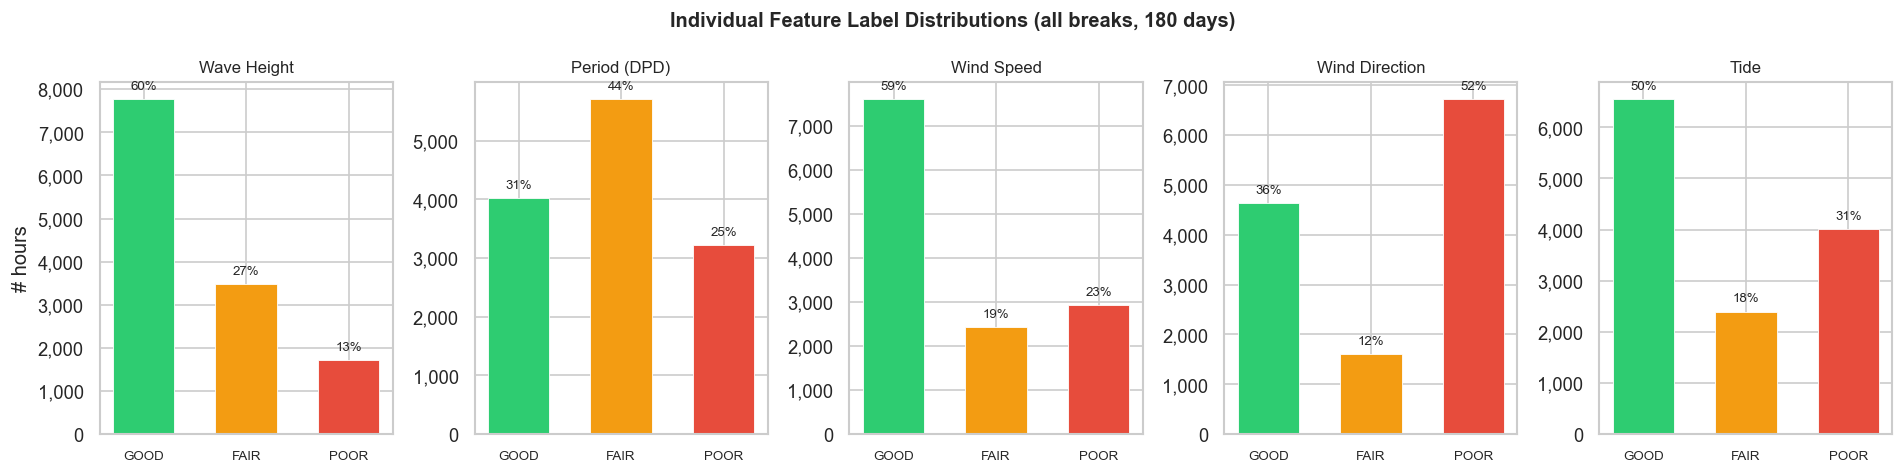

In [19]:
FEAT_META = {
    'wvht_label':        'Wave Height',
    'dpd_label':         'Period (DPD)',
    'wind_speed_label':  'Wind Speed',
    'wind_dir_label':    'Wind Direction',
    'tide_label':        'Tide',
}

fig, axes = plt.subplots(1, len(FEAT_META), figsize=(16, 4), sharey=False)

for ax, (col, title) in zip(axes, FEAT_META.items()):
    counts = df[col].value_counts().reindex(RATINGS, fill_value=0)
    pct    = (counts / counts.sum() * 100).round(1)
    bars   = ax.bar(counts.index, counts.values,
                    color=[COLORS[r] for r in counts.index],
                    edgecolor='white', linewidth=0.5, width=0.6)
    for bar, p in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + counts.max() * 0.02,
                f'{p:.0f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('# hours' if ax == axes[0] else '')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Individual Feature Label Distributions (all breaks, 180 days)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.4 — Overall Label Distribution & Class Imbalance

GOOD sessions require **multiple features aligning at once**, which is rare. The overall distribution reflects this — and reveals how severe the class imbalance problem will be for the classifier.

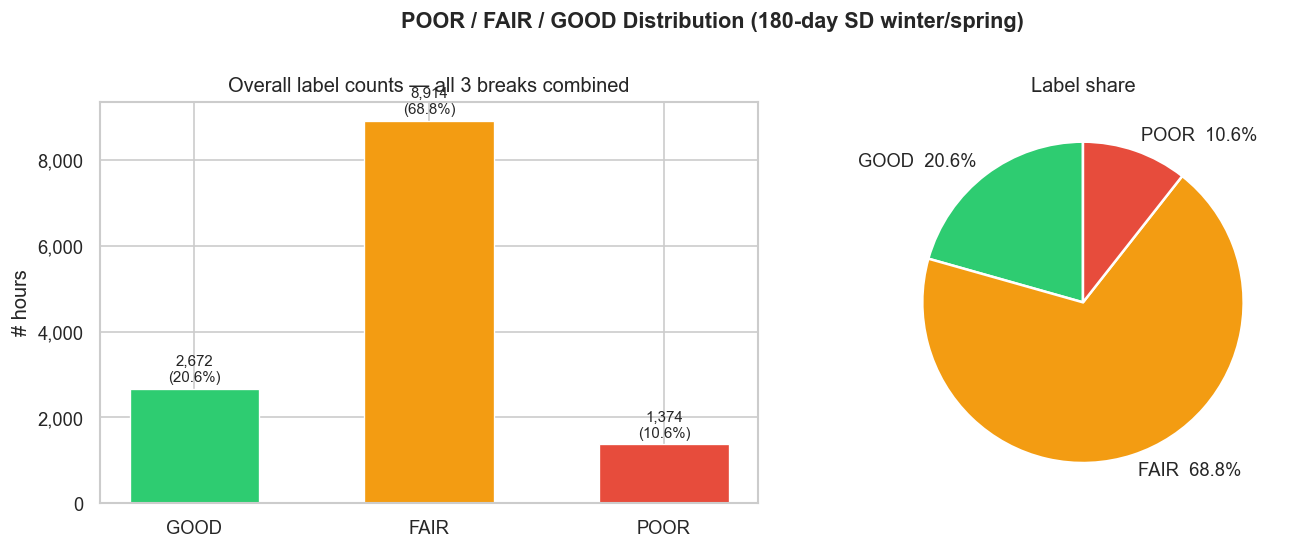

Majority class : FAIR  (8,914 hrs, 68.8%)
Minority class : POOR  (1,374 hrs, 10.6%)
Imbalance ratio: 6.5:1

Verdict: MODERATE — use class_weight="balanced" and stratified CV folds


In [20]:
overall     = df['rating'].value_counts().reindex(RATINGS, fill_value=0)
overall_pct = (overall / overall.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(overall.index, overall.values,
                   color=[COLORS[r] for r in overall.index],
                   edgecolor='white', linewidth=0.8, width=0.55)
for bar, cnt, pct in zip(bars, overall.values, overall_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + overall.max() * 0.01,
                 f'{cnt:,}\n({pct}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('# hours')
axes[0].set_title('Overall label counts — all 3 breaks combined')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(overall.values,
            labels=[f'{r}  {p}%' for r, p in zip(overall.index, overall_pct.values)],
            colors=[COLORS[r] for r in overall.index],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Label share')

plt.suptitle('POOR / FAIR / GOOD Distribution (180-day SD winter/spring)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Class imbalance report ──────────────────────────────────────────────────
majority = overall.idxmax()
minority = overall.idxmin()
ratio    = overall.max() / overall.min()

print(f"Majority class : {majority}  ({overall[majority]:,} hrs, {overall_pct[majority]}%)")
print(f"Minority class : {minority}  ({overall[minority]:,} hrs, {overall_pct[minority]}%)")
print(f"Imbalance ratio: {ratio:.1f}:1")
print()
if ratio > 10:
    verdict = 'SEVERE — class_weight="balanced" required; report F1-macro not accuracy'
elif ratio > 3:
    verdict = 'MODERATE — use class_weight="balanced" and stratified CV folds'
else:
    verdict = 'MANAGEABLE — standard training OK; still monitor per-class F1'
print(f"Verdict: {verdict}")


---

## 6 — Temporal Patterns: When Is Surf Actually Good?

*The diurnal wind cycle leaves a clear fingerprint in the label distribution.*

We already showed that wind roughly doubles from dawn to midday. Here we see the consequence in the ratings: GOOD sessions should cluster in the dawn window (5–10 am) and all-but-disappear in the afternoon.

**What to look for:**
- GOOD hours concentrated in the green dawn band
- POOR dominant in the red afternoon band  
- If the pattern is flat, the wind signal is not present in the data — investigate.


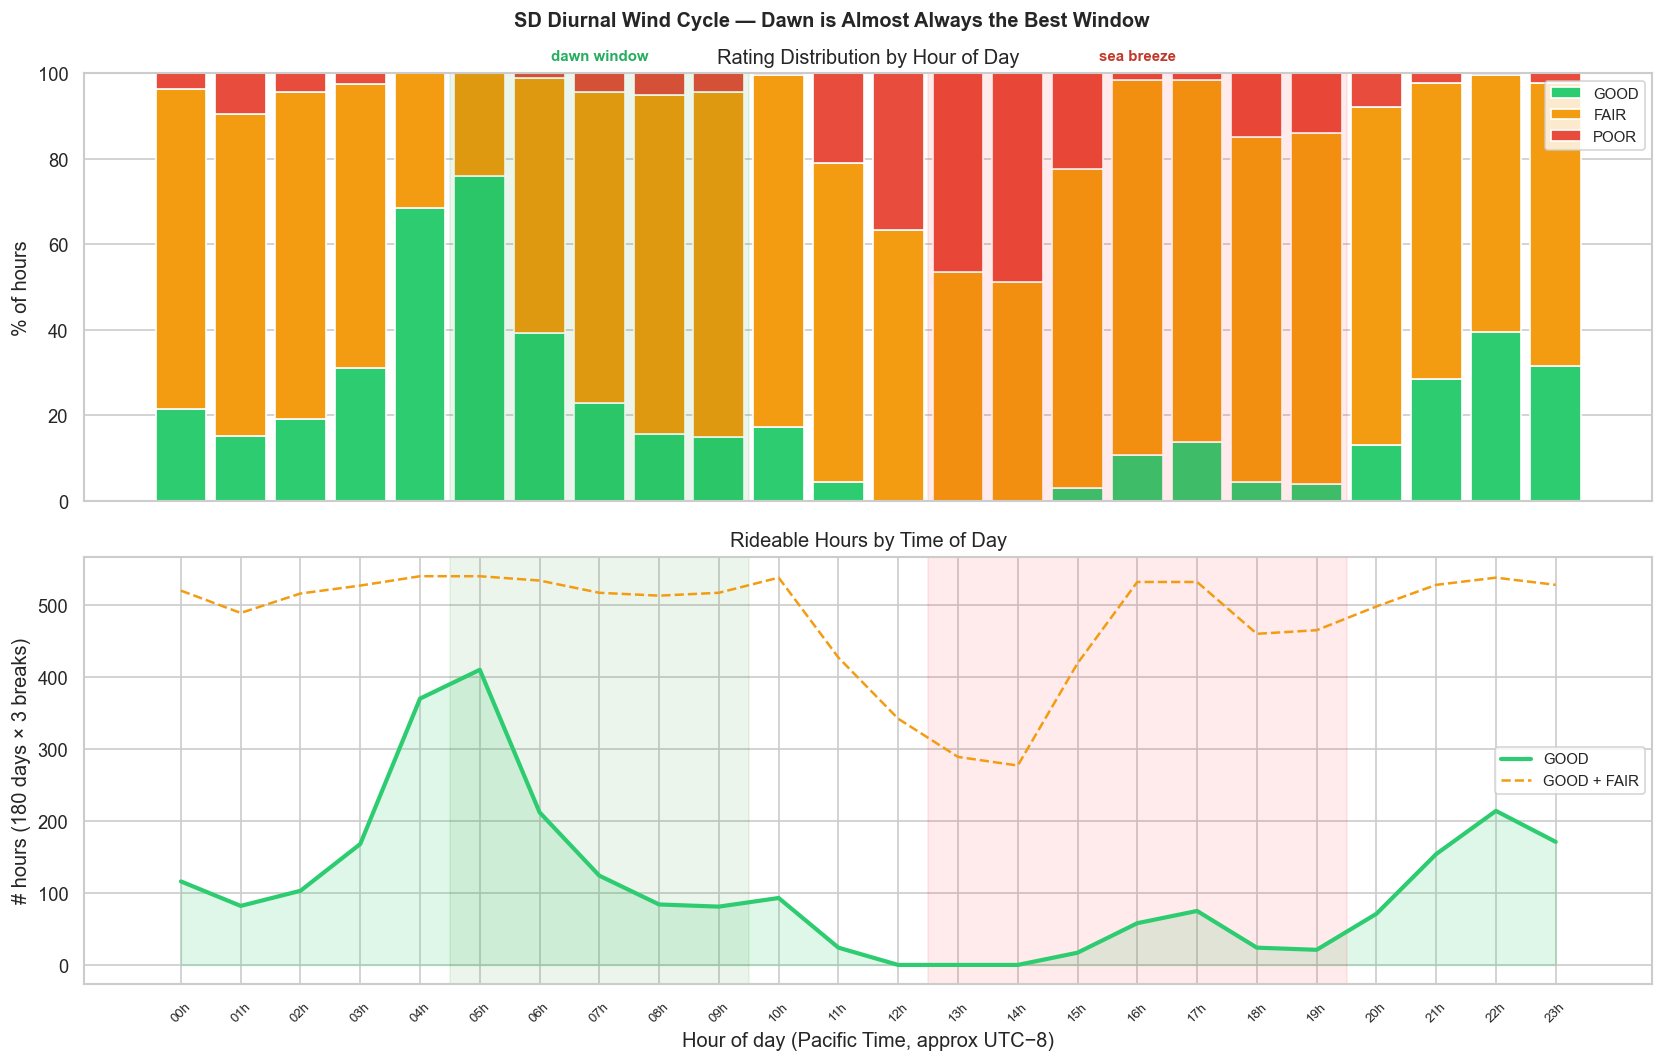

Peak GOOD hour: 05h Pacific


In [21]:
hourly = (
    df.groupby(['pacific_hour', 'rating']).size()
    .unstack(fill_value=0).reindex(columns=RATINGS, fill_value=0)
)
hourly_pct = hourly.div(hourly.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

bottom = np.zeros(len(hourly_pct))
for r in RATINGS:
    vals = hourly_pct[r].values
    axes[0].bar(hourly_pct.index, vals, bottom=bottom, color=COLORS[r], label=r, width=0.85)
    bottom += vals
axes[0].axvspan(4.5, 9.5,  alpha=0.08, color='green')
axes[0].axvspan(12.5, 19.5, alpha=0.08, color='red')
axes[0].text(7,  103, 'dawn window', ha='center', color='#27ae60', fontsize=9, fontweight='bold')
axes[0].text(16, 103, 'sea breeze',  ha='center', color='#c0392b', fontsize=9, fontweight='bold')
axes[0].set_ylabel('% of hours')
axes[0].set_title('Rating Distribution by Hour of Day')
axes[0].legend(loc='upper right', fontsize=9)

good_series = hourly.get('GOOD', pd.Series(0, index=hourly.index))
good_fair   = good_series + hourly.get('FAIR', pd.Series(0, index=hourly.index))
axes[1].plot(hourly.index, good_series, color='#2ecc71', linewidth=2.5, label='GOOD')
axes[1].fill_between(hourly.index, good_series, alpha=0.15, color='#2ecc71')
axes[1].plot(hourly.index, good_fair, color='#f39c12', linewidth=1.5, linestyle='--', label='GOOD + FAIR')
axes[1].axvspan(4.5, 9.5,  alpha=0.08, color='green')
axes[1].axvspan(12.5, 19.5, alpha=0.08, color='red')
axes[1].set_ylabel('# hours (180 days × 3 breaks)')
axes[1].set_title('Rideable Hours by Time of Day')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(24))
axes[1].set_xticklabels([f'{h:02d}h' for h in range(24)], rotation=45, fontsize=8)
axes[1].set_xlabel('Hour of day (Pacific Time, approx UTC−8)')

plt.suptitle("SD Diurnal Wind Cycle — Dawn is Almost Always the Best Window",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

peak = int(good_series.idxmax())
print(f"Peak GOOD hour: {peak:02d}h Pacific")


---

## 7 — Per-Break Rating Distribution

All three breaks receive the same swell, but each has a different preferred tide window and slightly different wind exposure. Do these differences produce meaningfully different rating distributions?

**What to look for:**
- If distributions are nearly identical → break identity doesn't matter much; one model covers all three
- If distributions differ → `break_id` should be a feature, or we train separate per-break models
- The GOOD column is the most interesting: which break gets more GOOD hours and why?


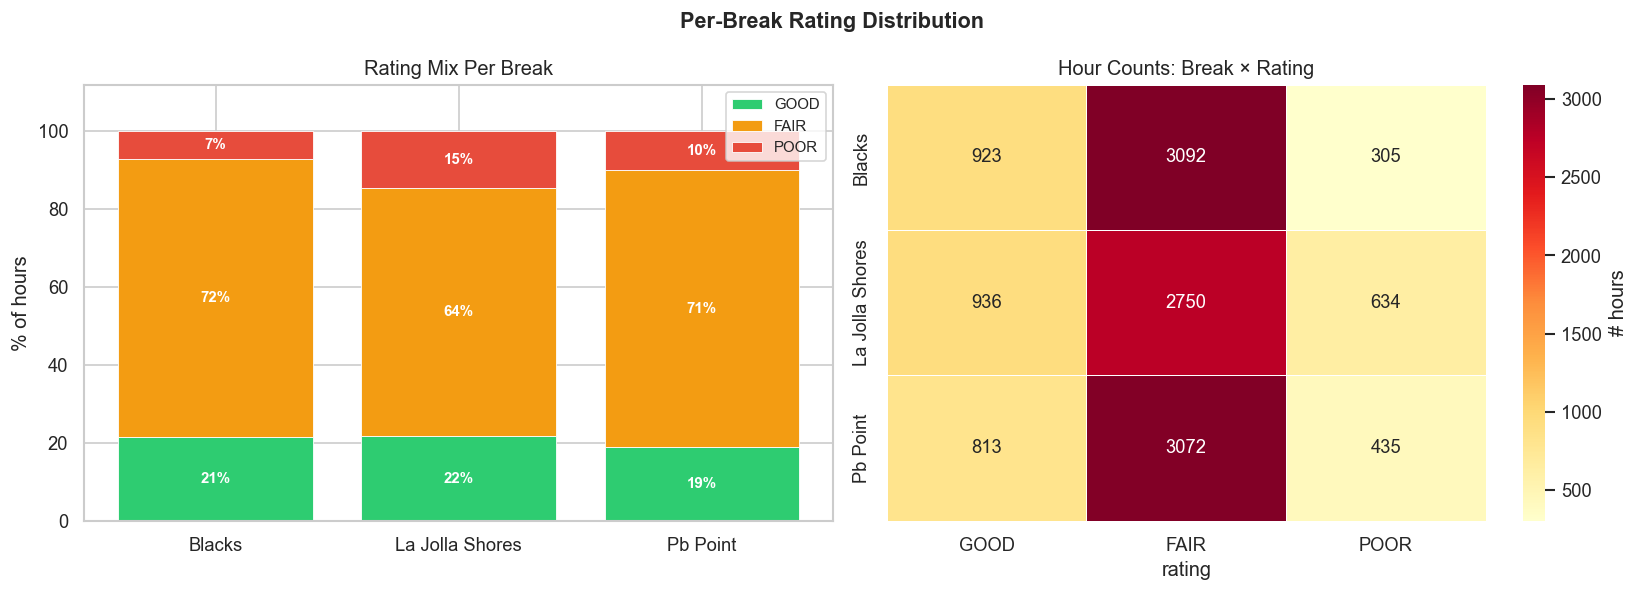

Per-break % breakdown:
rating           GOOD  FAIR  POOR
break                            
Blacks           21.4  71.6   7.1
La Jolla Shores  21.7  63.7  14.7
Pb Point         18.8  71.1  10.1

Most variable label across breaks: FAIR (7.9pp spread)


In [22]:
per_break = (
    df.groupby(['break', 'rating']).size()
    .unstack(fill_value=0).reindex(columns=RATINGS, fill_value=0)
)
per_break_pct = per_break.div(per_break.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bottom  = np.zeros(len(per_break_pct))
xlabels = [BREAK_LABELS[b] for b in per_break_pct.index]

for r in RATINGS:
    vals = per_break_pct[r].values
    axes[0].bar(xlabels, vals, bottom=bottom, color=COLORS[r],
                label=r, edgecolor='white', linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            axes[0].text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                         fontsize=9, color='white', fontweight='bold')
    bottom += vals
axes[0].set_ylabel('% of hours')
axes[0].set_title('Rating Mix Per Break')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_ylim(0, 112)

sns.heatmap(per_break.rename(index=BREAK_LABELS),
            annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '# hours'})
axes[1].set_title('Hour Counts: Break × Rating')
axes[1].set_ylabel('')

plt.suptitle('Per-Break Rating Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Per-break % breakdown:")
print(per_break_pct.rename(index=BREAK_LABELS).round(1).to_string())

spread        = per_break_pct.max() - per_break_pct.min()
most_variable = spread.idxmax()
print(f"\nMost variable label across breaks: {most_variable} ({spread[most_variable]:.1f}pp spread)")


---

## 8 — Pairwise Break Agreement

At any given hour, how often do Blacks, La Jolla Shores, and PB Point get the **same** overall rating? Since they share the same swell input, any disagreement is caused entirely by differences in wind direction exposure and tide preference.

High agreement → breaks are interchangeable → a single shared model is appropriate.  
Low agreement → breaks behave independently → break-specific features or separate models will help.


All 3 breaks same rating:   63.9%
At least one break differs: 36.1%


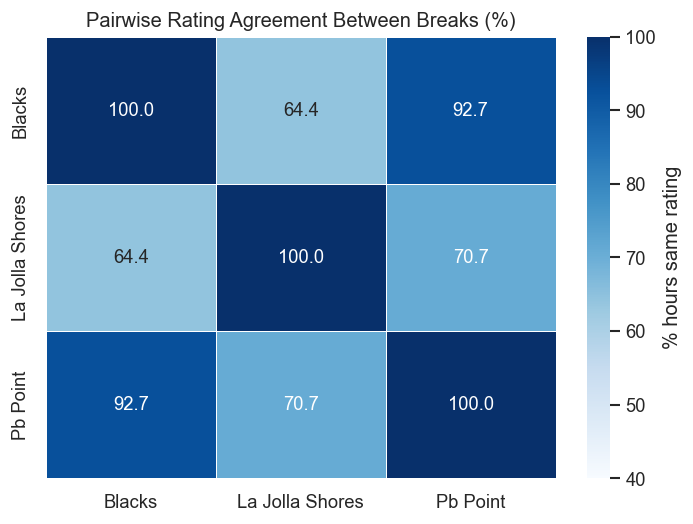

In [23]:
pivot = (
    df.pivot_table(index='hour_utc', columns='break', values='rating', aggfunc='first')
    [BREAK_KEYS].dropna()
)

agree_matrix = pd.DataFrame(index=BREAK_KEYS, columns=BREAK_KEYS, dtype=float)
for a in BREAK_KEYS:
    for b in BREAK_KEYS:
        agree_matrix.loc[a, b] = (pivot[a] == pivot[b]).mean() * 100

all_agree_pct = pivot.apply(lambda r: r.nunique() == 1, axis=1).mean() * 100
print(f"All 3 breaks same rating:   {all_agree_pct:.1f}%")
print(f"At least one break differs: {100 - all_agree_pct:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(
    agree_matrix.rename(index=BREAK_LABELS, columns=BREAK_LABELS).astype(float),
    annot=True, fmt='.1f', cmap='Blues', vmin=40, vmax=100,
    linewidths=0.5, ax=ax, cbar_kws={'label': '% hours same rating'}
)
ax.set_title('Pairwise Rating Agreement Between Breaks (%)')
plt.tight_layout()
plt.show()


---

## 9 — Labeling Strategy: Per-Feature vs Direct Scoring

The per-feature approach used above is not the only way to derive a session rating. The existing `etl/score_surf.py` proxy scorer goes **directly** from raw numbers to an overall rating in one step — no intermediate feature labels.

| | Per-feature labeling | Direct scoring |
|---|---|---|
| Intermediate step | Yes — each feature gets its own POOR/FAIR/GOOD | No — raw values → overall rating |
| How GOOD is assigned | Enough features score high on average | **All** conditions simultaneously cleared |
| A bad tide with great swell… | Can still average to FAIR | Gets knocked to POOR by hard rules |
| Best use | Feature engineering for the classifier | Quick human-readable heuristic |

The key question: how much do they agree, and where do they diverge?


In [26]:
def rate_direct(wvht_m, dpd, wind_mph, wind_dir, tide_ft_val, brk):
    """Rate surf quality directly from raw values — no intermediate feature labels."""    
    ft         = wvht_m * 3.281
    delta      = abs((wind_dir - 90 + 180) % 360 - 180)
    offshore   = delta <= 45
    tlo, thi   = TIDE_WIN[brk]
    good_tide  = tlo <= tide_ft_val <= thi
    wind_limit = 18 if dpd > 18 else 15

    if (3.3 <= ft <= 8.2 and dpd >= 12 and wind_mph <= wind_limit
            and offshore and good_tide):
        return 'GOOD'
    if ft < 1.6 or ft > 9.8:         return 'POOR'
    if dpd < 8:                       return 'POOR'
    if not offshore and wind_mph > 15: return 'POOR'
    return 'FAIR'

dir_frames = []
for brk, offset in offsets.items():
    d = base_df.copy()
    d['break']          = brk
    d['wind_dir_break'] = (d['wind_dir'] + offset) % 360
    d['rating_direct']  = d.apply(
        lambda r: rate_direct(r.wvht, r.dpd, r.wind_mph, r.wind_dir_break, r.tide_ft, brk), axis=1
    )
    dir_frames.append(d)

df_direct = pd.concat(dir_frames, ignore_index=True)

direct_overall     = df_direct['rating_direct'].value_counts().reindex(RATINGS, fill_value=0)
direct_overall_pct = (direct_overall / direct_overall.sum() * 100).round(1)

print("Direct scorer — overall distribution:")
for r in RATINGS:
    print(f"   {r:>5s}: {direct_overall[r]:>7,} hrs  ({direct_overall_pct[r]:.1f}%)")
d_ratio = direct_overall.max() / direct_overall[direct_overall > 0].min()
print(f"\nImbalance ratio: {d_ratio:.1f}:1")


Direct scorer — overall distribution:
    GOOD:     360 hrs  (2.8%)
    FAIR:   7,043 hrs  (54.3%)
    POOR:   5,557 hrs  (42.9%)

Imbalance ratio: 19.6:1


Overall agreement between approaches: 51.3%
Disagree on 48.7% of sessions



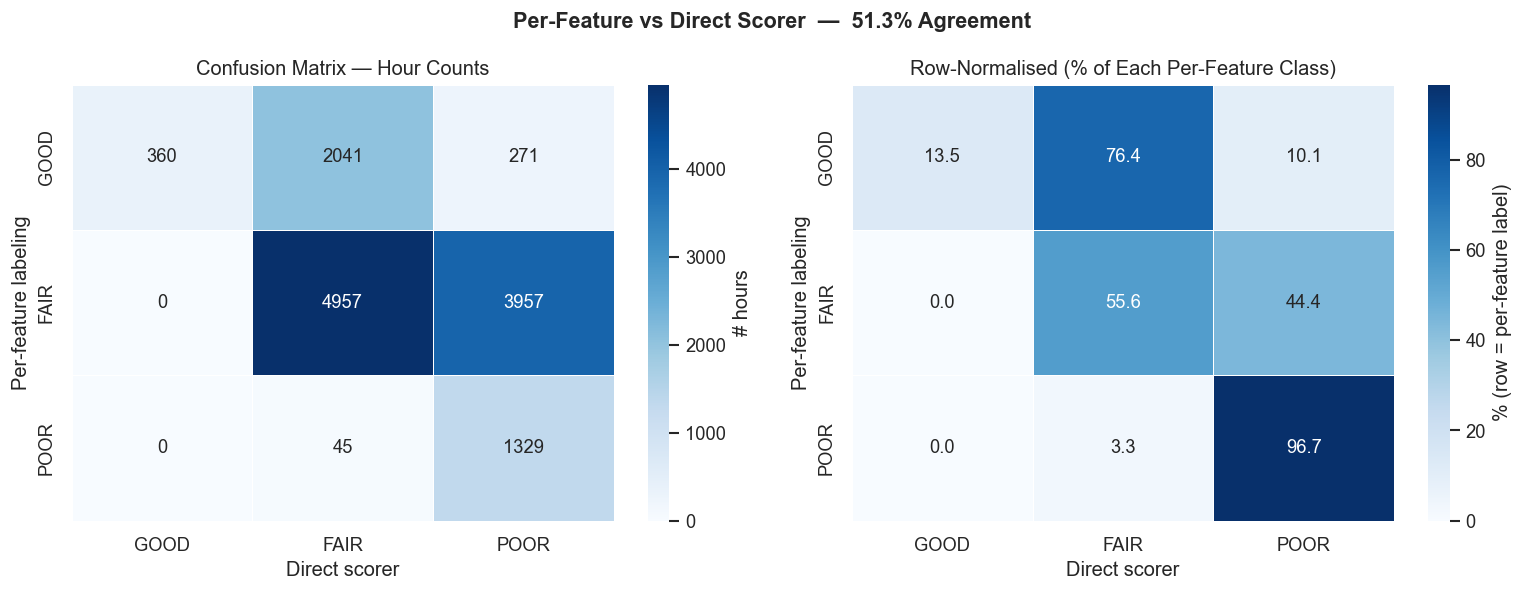

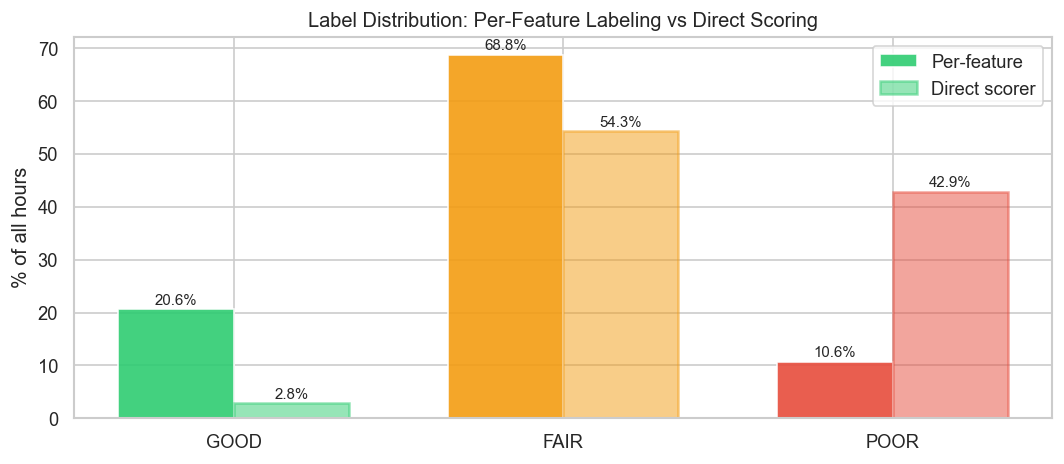

In [27]:
compare = df[['hour_utc', 'break', 'rating']].copy()
compare['rating_direct'] = df_direct['rating_direct'].values
agreement = (compare['rating'] == compare['rating_direct']).mean() * 100

print(f"Overall agreement between approaches: {agreement:.1f}%")
print(f"Disagree on {100 - agreement:.1f}% of sessions\n")

conf = (
    compare.groupby(['rating', 'rating_direct']).size()
    .unstack(fill_value=0).reindex(index=RATINGS, columns=RATINGS, fill_value=0)
)
conf_pct = conf.div(conf.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=axes[0],
            cbar_kws={'label': '# hours'})
axes[0].set_xlabel('Direct scorer'); axes[0].set_ylabel('Per-feature labeling')
axes[0].set_title('Confusion Matrix — Hour Counts')

sns.heatmap(conf_pct, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5, ax=axes[1],
            cbar_kws={'label': '% (row = per-feature label)'})
axes[1].set_xlabel('Direct scorer'); axes[1].set_ylabel('Per-feature labeling')
axes[1].set_title('Row-Normalised (% of Each Per-Feature Class)')

plt.suptitle(f'Per-Feature vs Direct Scorer  —  {agreement:.1f}% Agreement',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Side-by-side bar comparison
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(RATINGS)); w = 0.35
feat_pct   = [overall_pct[r] for r in RATINGS]
direct_pct = [direct_overall_pct[r] for r in RATINGS]

b1 = ax.bar(x - w/2, feat_pct,   w, label='Per-feature',  color=[COLORS[r] for r in RATINGS], alpha=0.9)
b2 = ax.bar(x + w/2, direct_pct, w, label='Direct scorer', color=[COLORS[r] for r in RATINGS], alpha=0.5,
            edgecolor=[COLORS[r] for r in RATINGS], linewidth=1.5)
for bar, v in zip(b1, feat_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9)
for bar, v in zip(b2, direct_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(RATINGS)
ax.set_ylabel('% of all hours')
ax.set_title('Label Distribution: Per-Feature Labeling vs Direct Scoring')
ax.legend()
plt.tight_layout()
plt.show()


**Takeaway:** The direct scorer is strict — all conditions must clear the bar simultaneously for GOOD, and one dealbreaker flips to POOR. The per-feature labeler is more forgiving — a great swell can compensate for a so-so tide and still average to FAIR.

For the classifier, **use per-feature labels as model inputs and per-feature overall rating as the target.** The direct scorer is a useful rules-based baseline to beat.


---

## 10 — Key Findings & Model Implications


In [28]:
print('LABEL ANALYSIS — KEY FINDINGS')
print('=' * 55)

print('\n1. OVERALL DISTRIBUTION')
for r in RATINGS:
    print(f'   {r:>5s}: {overall[r]:>7,} hrs  ({overall_pct[r]:.1f}%)')

print(f'\n2. CLASS IMBALANCE: {ratio:.1f}:1')
print(f'   {verdict}')

print('\n3. PER-BREAK BREAKDOWN')
for brk in BREAK_KEYS:
    row   = per_break_pct.loc[brk]
    parts = '  '.join(f'{r}: {row[r]:.0f}%' for r in RATINGS)
    print(f'   {BREAK_LABELS[brk]:22s}  {parts}')

spread        = per_break_pct.max() - per_break_pct.min()
most_variable = spread.idxmax()
print(f'\n   Most variable label across breaks: {most_variable} ({spread[most_variable]:.1f}pp spread)')

print(f'\n4. INTER-BREAK AGREEMENT: {all_agree_pct:.1f}% of hours all three breaks get the same rating')
print(f'   {100 - all_agree_pct:.1f}% diverge → break_id is a meaningful feature')

peak = int(good_series.idxmax())
print(f'\n5. TIME OF DAY: peak GOOD hour is {peak:02d}h Pacific')
print('   Dawn window (05h–10h) concentrates the majority of GOOD sessions')
print('   → hour_of_day (or sin/cos encoding) must be included in the feature set')

print('\n6. GEOGRAPHIC VALIDATION')
print('   West swell → Blacks and PB Point favoured; La Jolla disfavoured')
print('   South swell → La Jolla favoured; Blacks and PB disfavoured')
print('   → Per-break direction score should be a strong predictor')

print('\n7. WIND IS THE PRIMARY FILTER')
print('   Wind speed roughly doubles dawn→midday at every break')
print('   → A binary `morning` feature (before 11am) cleanly separates the regimes')
print('   → Wind direction adds limited info beyond speed for these three breaks')


LABEL ANALYSIS — KEY FINDINGS

1. OVERALL DISTRIBUTION
    GOOD:   2,672 hrs  (20.6%)
    FAIR:   8,914 hrs  (68.8%)
    POOR:   1,374 hrs  (10.6%)

2. CLASS IMBALANCE: 6.5:1
   MODERATE — use class_weight="balanced" and stratified CV folds

3. PER-BREAK BREAKDOWN
   Blacks                  GOOD: 21%  FAIR: 72%  POOR: 7%
   La Jolla Shores         GOOD: 22%  FAIR: 64%  POOR: 15%
   Pb Point                GOOD: 19%  FAIR: 71%  POOR: 10%

   Most variable label across breaks: FAIR (7.9pp spread)

4. INTER-BREAK AGREEMENT: 63.9% of hours all three breaks get the same rating
   36.1% diverge → break_id is a meaningful feature

5. TIME OF DAY: peak GOOD hour is 05h Pacific
   Dawn window (05h–10h) concentrates the majority of GOOD sessions
   → hour_of_day (or sin/cos encoding) must be included in the feature set

6. GEOGRAPHIC VALIDATION
   West swell → Blacks and PB Point favoured; La Jolla disfavoured
   South swell → La Jolla favoured; Blacks and PB disfavoured
   → Per-break direction